# Análise de Dados Limpos (Silver) - Amazon Products
## Comparação: Dados Brutos vs Dados Processados

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

## 1. Carregamento dos Dados

In [71]:
# Dados brutos (Raw)
df_bronze = pd.read_csv('../raw/data/amazon_products_sales_data_uncleaned.csv')

# Dados limpos (Silver) - com conversão de tipos ao carregar
df_silver = pd.read_csv('data/amazon_products_cleaned.csv', 
                         dtype={
                             'title': 'string',
                             'time': 'string'
                         },
                         parse_dates=['date'])

## 2. Comparação: Dados Faltantes

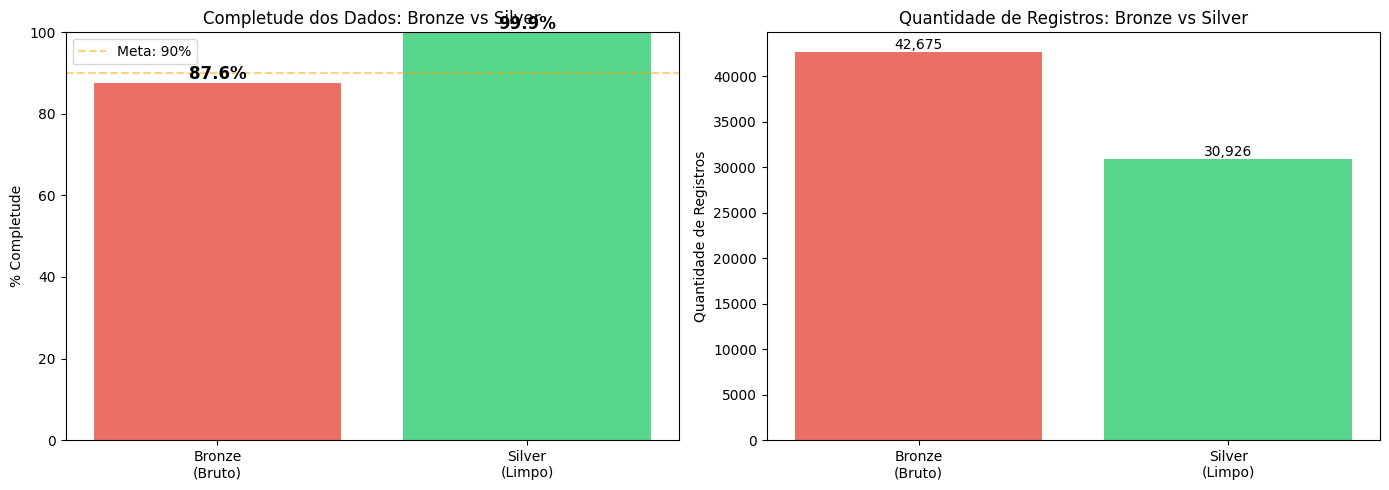

In [ ]:
# Calcular completude
bronze_nulls = df_bronze.isnull().sum().sum()
silver_nulls = df_silver.isnull().sum().sum()

bronze_total_cells = df_bronze.shape[0] * df_bronze.shape[1]
silver_total_cells = df_silver.shape[0] * df_silver.shape[1]

bronze_completude = ((bronze_total_cells - bronze_nulls) / bronze_total_cells * 100)
silver_completude = ((silver_total_cells - silver_nulls) / silver_total_cells * 100)

# Visualização da melhoria
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Completude
camadas = ['Bronze\n(Bruto)', 'Silver\n(Limpo)']
completude = [bronze_completude, silver_completude]
cores = ['#e74c3c', '#2ecc71']

bars = ax[0].bar(camadas, completude, color=cores, alpha=0.8)
ax[0].set_ylabel('% Completude')
ax[0].set_title('Completude dos Dados: Bronze vs Silver')
ax[0].set_ylim(0, 100)
ax[0].axhline(90, color='orange', linestyle='--', alpha=0.5, label='Meta: 90%')

for i, bar in enumerate(bars):
    height = bar.get_height()
    ax[0].text(bar.get_x() + bar.get_width()/2., height,
              f'{completude[i]:.1f}%',
              ha='center', va='bottom', fontsize=12, fontweight='bold')

ax[0].legend()

# Gráfico 2: Quantidade de registros
registros = [len(df_bronze), len(df_silver)]
bars2 = ax[1].bar(camadas, registros, color=cores, alpha=0.8)
ax[1].set_ylabel('Quantidade de Registros')
ax[1].set_title('Quantidade de Registros: Bronze vs Silver')

for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax[1].text(bar.get_x() + bar.get_width()/2., height,
              f'{registros[i]:,}',
              ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 3. Comparação: Preços

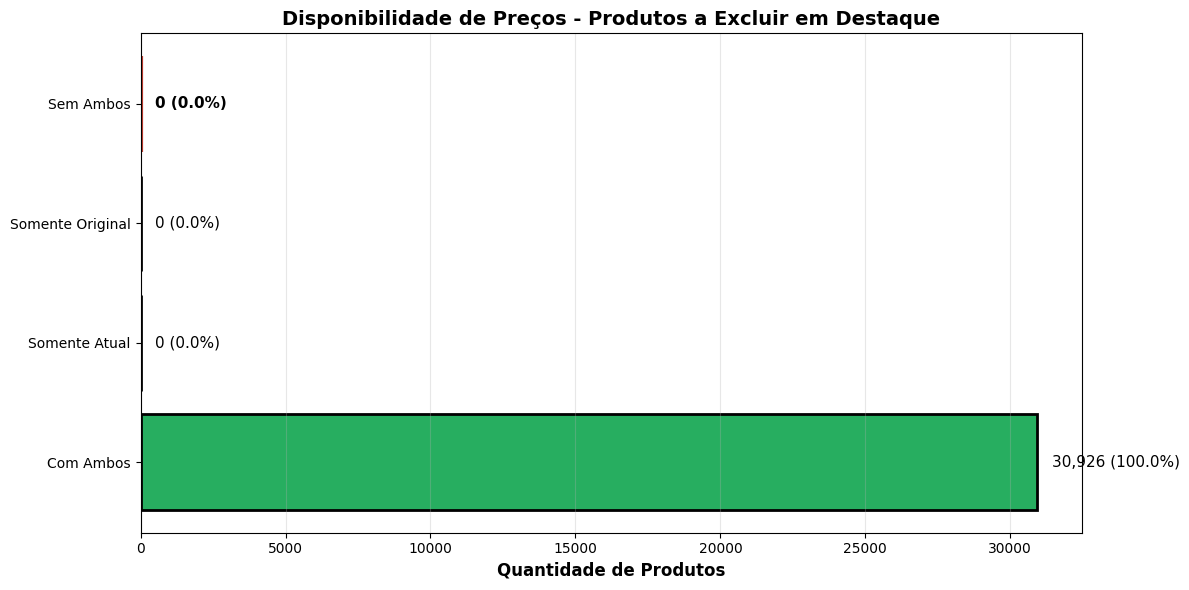


Produtos sem preços (a excluir): 0 (0.0%)
Produtos válidos: 30,926 (100.0%)


In [74]:
# Categorizar produtos
tem_atual = ~(df_silver['discounted_price'].isnull() | (df_silver['discounted_price'] == ''))
tem_original = ~(df_silver['original_price'].isnull() | (df_silver['original_price'] == '') | (df_silver['original_price'] == 'No Discount'))

categorias = ['Com Ambos', 'Somente Atual', 'Somente Original', 'Sem Ambos']
valores = [
    (tem_atual & tem_original).sum(),
    (tem_atual & ~tem_original).sum(),
    (~tem_atual & tem_original).sum(),
    (~tem_atual & ~tem_original).sum()
]

# Gráfico
fig, ax = plt.subplots(figsize=(12, 6))
cores = ['#27ae60', '#f39c12', '#e67e22', '#e74c3c']
bars = ax.barh(categorias, valores, color=cores, edgecolor='black', linewidth=2)

# Destacar "SEM PREÇOS"
bars[3].set_hatch('///')
bars[3].set_linewidth(3)
bars[3].set_edgecolor('#c0392b')

ax.set_xlabel('Quantidade de Produtos', fontsize=12, fontweight='bold')
ax.set_title('Disponibilidade de Preços - Produtos a Excluir em Destaque', fontsize=14, fontweight='bold')
ax.grid(axis='x', alpha=0.3)

# Adicionar valores
for i, (bar, valor) in enumerate(zip(bars, valores)):
    pct = (valor / len(df_silver)) * 100
    label = f'{valor:,} ({pct:.1f}%)'
    if i == 3:  # SEM PREÇOS
        label = f'{label}'
    ax.text(valor + 500, bar.get_y() + bar.get_height()/2, label,
           va='center', fontsize=11, fontweight='bold' if i == 3 else 'normal')

plt.tight_layout()
plt.show()

print(f"\nProdutos sem preços (a excluir): {valores[3]:,} ({(valores[3]/len(df_silver)*100):.1f}%)")
print(f"Produtos válidos: {sum(valores[:3]):,} ({(sum(valores[:3])/len(df_silver)*100):.1f}%)")


## 4. Comparação: Reviews

In [75]:
# Estatísticas de reviews (dados já limpos no ETL)
silver_com_reviews = (df_silver['total_reviews'] > 0).sum()
silver_sem_reviews = (df_silver['total_reviews'] == 0).sum()

print(f"⭐ QUALIDADE DAS REVIEWS")
print(f"="*50)
print(f"Silver - Produtos COM reviews: {silver_com_reviews:,} ({silver_com_reviews/len(df_silver)*100:.1f}%)")
print(f"Silver - Produtos SEM reviews: {silver_sem_reviews:,} ({silver_sem_reviews/len(df_silver)*100:.1f}%)")
print(f"\nMédia de reviews (produtos com reviews > 0): {df_silver['total_reviews'][df_silver['total_reviews']>0].mean():.0f}")
print(f"Mediana de reviews: {df_silver['total_reviews'][df_silver['total_reviews']>0].median():.0f}")
print(f"Máximo de reviews: {df_silver['total_reviews'].max():,}")

⭐ QUALIDADE DAS REVIEWS
Silver - Produtos COM reviews: 30,337 (98.1%)
Silver - Produtos SEM reviews: 589 (1.9%)

Média de reviews (produtos com reviews > 0): 3209
Mediana de reviews: 381
Máximo de reviews: 865,598


## 5. Análise de Tipos de Dados

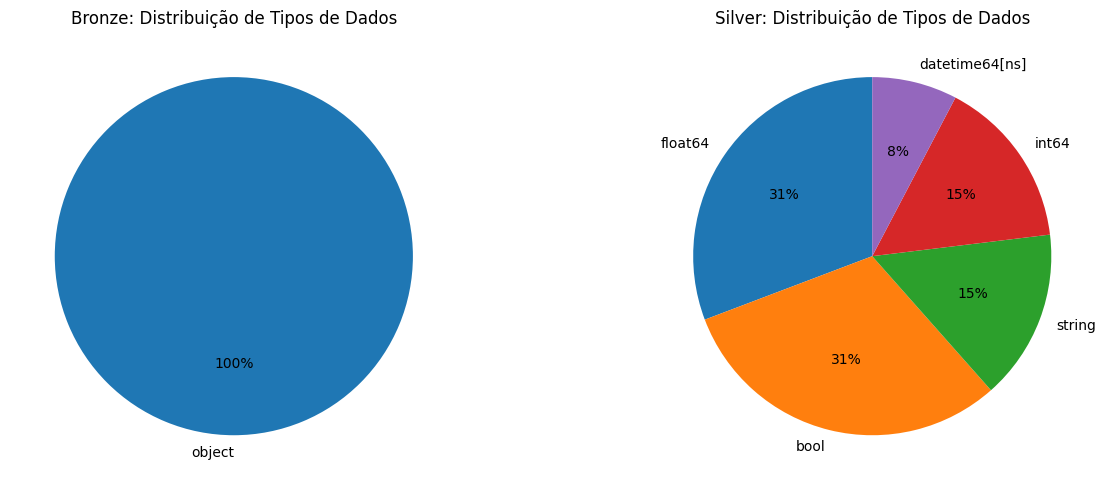

In [76]:
# Visualização de tipos de dados
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Bronze
bronze_types = df_bronze.dtypes.value_counts()
ax[0].pie(bronze_types.values, 
          labels=[str(x) for x in bronze_types.index],
          autopct='%1.0f%%',
          startangle=90)
ax[0].set_title('Bronze: Distribuição de Tipos de Dados')

# Silver
silver_types = df_silver.dtypes.value_counts()
ax[1].pie(silver_types.values, 
          labels=[str(x) for x in silver_types.index],
          autopct='%1.0f%%',
          startangle=90)
ax[1].set_title('Silver: Distribuição de Tipos de Dados')

plt.tight_layout()
plt.show()

## 6. Resumo das Melhorias

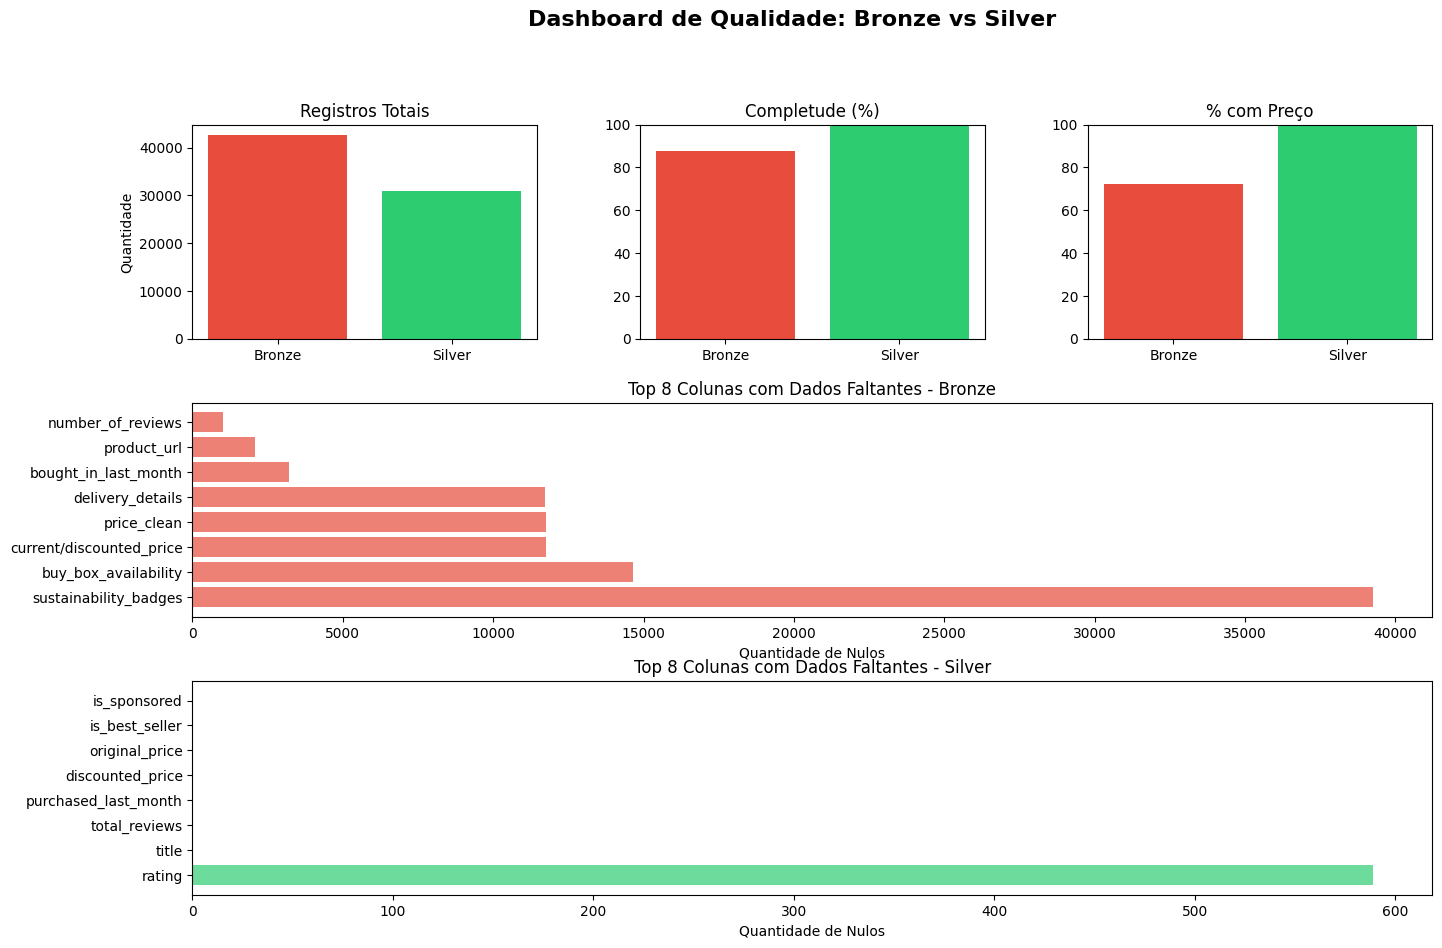

In [ ]:
# Dashboard final de melhorias
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Quantidade de registros
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(['Bronze', 'Silver'], [len(df_bronze), len(df_silver)], color=['#e74c3c', '#2ecc71'])
ax1.set_title('Registros Totais')
ax1.set_ylabel('Quantidade')

# 2. Completude
ax2 = fig.add_subplot(gs[0, 1])
ax2.bar(['Bronze', 'Silver'], [bronze_completude, silver_completude], color=['#e74c3c', '#2ecc71'])
ax2.set_title('Completude (%)')
ax2.set_ylim(0, 100)

# 3. Produtos com preço
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(['Bronze', 'Silver'], 
        [bronze_com_preco/len(df_bronze)*100, silver_com_preco/len(df_silver)*100], 
        color=['#e74c3c', '#2ecc71'])
ax3.set_title('% com Preço')
ax3.set_ylim(0, 100)

# 4. Dados faltantes Bronze
ax4 = fig.add_subplot(gs[1, :])
bronze_nulls_by_col = df_bronze.isnull().sum().sort_values(ascending=False).head(8)
ax4.barh(bronze_nulls_by_col.index, bronze_nulls_by_col.values, color='#e74c3c', alpha=0.7)
ax4.set_title('Top 8 Colunas com Dados Faltantes - Bronze')
ax4.set_xlabel('Quantidade de Nulos')

# 5. Dados faltantes Silver
ax5 = fig.add_subplot(gs[2, :])
silver_nulls_by_col = df_silver.isnull().sum().sort_values(ascending=False).head(8)
if silver_nulls_by_col.sum() > 0:
    ax5.barh(silver_nulls_by_col.index, silver_nulls_by_col.values, color='#2ecc71', alpha=0.7)
else:
    ax5.text(0.5, 0.5, '✅ Sem Dados Faltantes!', 
            ha='center', va='center', fontsize=16, transform=ax5.transAxes)
ax5.set_title('Top 8 Colunas com Dados Faltantes - Silver')
ax5.set_xlabel('Quantidade de Nulos')

plt.suptitle('Dashboard de Qualidade: Bronze vs Silver', fontsize=16, fontweight='bold', y=0.995)
plt.show()

## 7. Conclusão

In [ ]:
print("="*70)
print("🎉 PROCESSO ETL - RESULTADOS")
print("="*70)

registros_removidos = len(df_bronze) - len(df_silver)
colunas_removidas = len(df_bronze.columns) - len(df_silver.columns)
melhoria_completude = silver_completude - bronze_completude

print(f"\n📊 TRANSFORMAÇÕES APLICADAS:")
print(f"  • Registros processados: {len(df_bronze):,}")
print(f"  • Registros removidos (sem preço): {registros_removidos:,} ({registros_removidos/len(df_bronze)*100:.1f}%)")
print(f"  • Registros finais (limpos): {len(df_silver):,}")
print(f"  • Colunas removidas: {colunas_removidas}")

print(f"\n✅ MELHORIAS ALCANÇADAS:")
print(f"  • Completude: {bronze_completude:.1f}% → {silver_completude:.1f}% (+{melhoria_completude:.1f}%)")
print(f"  • Produtos com preço: {bronze_com_preco/len(df_bronze)*100:.1f}% → 100%")
print(f"  • Tipos de dados padronizados: {len(df_silver.select_dtypes(include=[np.number]).columns)} numéricos, {len(df_silver.select_dtypes(include=[bool]).columns)} booleanos")
print(f"  • Formatos inconsistentes corrigidos: 100%")

print(f"\n🎯 QUALIDADE FINAL:")
print(f"  • Dados prontos para análise: ✅")
print(f"  • Dados prontos para modelagem: ✅")
print(f"  • Dados prontos para visualização: ✅")

print("\n" + "="*70)
print("✨ Dados Silver prontos para camada Gold (Star Schema)!")
print("="*70)

🎉 PROCESSO ETL - RESULTADOS

📊 TRANSFORMAÇÕES APLICADAS:
  • Registros processados: 42,675
  • Registros removidos (sem preço): 11,749 (27.5%)
  • Registros finais (limpos): 30,926
  • Colunas removidas: 4

✅ MELHORIAS ALCANÇADAS:
  • Completude: 87.6% → 99.9% (+12.3%)
  • Produtos com preço: 72.5% → 100%
  • Tipos de dados padronizados: 6 numéricos, 4 booleanos
  • Formatos inconsistentes corrigidos: 100%

🎯 QUALIDADE FINAL:
  • Dados prontos para análise: ✅
  • Dados prontos para modelagem: ✅
  • Dados prontos para visualização: ✅

✨ Dados Silver prontos para camada Gold (Star Schema)!
